# Visualizing LeRobot Dataset Validation Results

This notebook visualizes the output of `scripts/validate_lerobot_dataset.py`. 

The script generates three main CSV files in the output directory (default: `dataset_validation_out`):
1. `within_episode_d1.csv`: Stationarity results for each dimension and episode.
2. `episode_metrics.csv`: Raw metrics per episode (length, variation, initial state).
3. `across_episode_drift.csv`: Kruskal-Wallis drift test results.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Ensure plots render inline
%matplotlib inline
sns.set_theme(style="whitegrid")

In [8]:
# =============================================================================
# CONFIGURATION
# =============================================================================
OUT_DIR = Path("../dataset_validation_results")
DIFF_ORDER = 1  # Should match the --diff-order used in the script
ALPHA = 0.05    # Significance level
STREAM = "action" # Stream to visualize in heatmap ("action" or "observation.state")
# =============================================================================

## Load Results

In [9]:
within_path = OUT_DIR / f"within_episode_d{DIFF_ORDER}.csv"
metrics_path = OUT_DIR / "episode_metrics.csv"
drift_path = OUT_DIR / "across_episode_drift.csv"

if not within_path.exists():
    print(f"❌ Could not find {within_path}.")
else:
    df_within = pd.read_csv(within_path)
    print(f"✅ Loaded within-episode results: {len(df_within)} rows")

if not metrics_path.exists():
    print(f"❌ Could not find {metrics_path}. Re-run script to generate.")
else:
    df_metrics = pd.read_csv(metrics_path)
    print(f"✅ Loaded episode metrics: {len(df_metrics)} rows")

if not drift_path.exists():
    print(f"❌ Could not find {drift_path}.")
else:
    df_drift = pd.read_csv(drift_path)
    print(f"✅ Loaded drift results: {len(df_drift)} rows")

✅ Loaded within-episode results: 10452 rows
✅ Loaded episode metrics: 201 rows
✅ Loaded drift results: 79 rows


## Phase 1: Within-Episode Stationarity (Smoothness)

Heatmap of stationarity verdicts. Ideally, robot actions should be **Stationary** or **Difference-Stationary**.

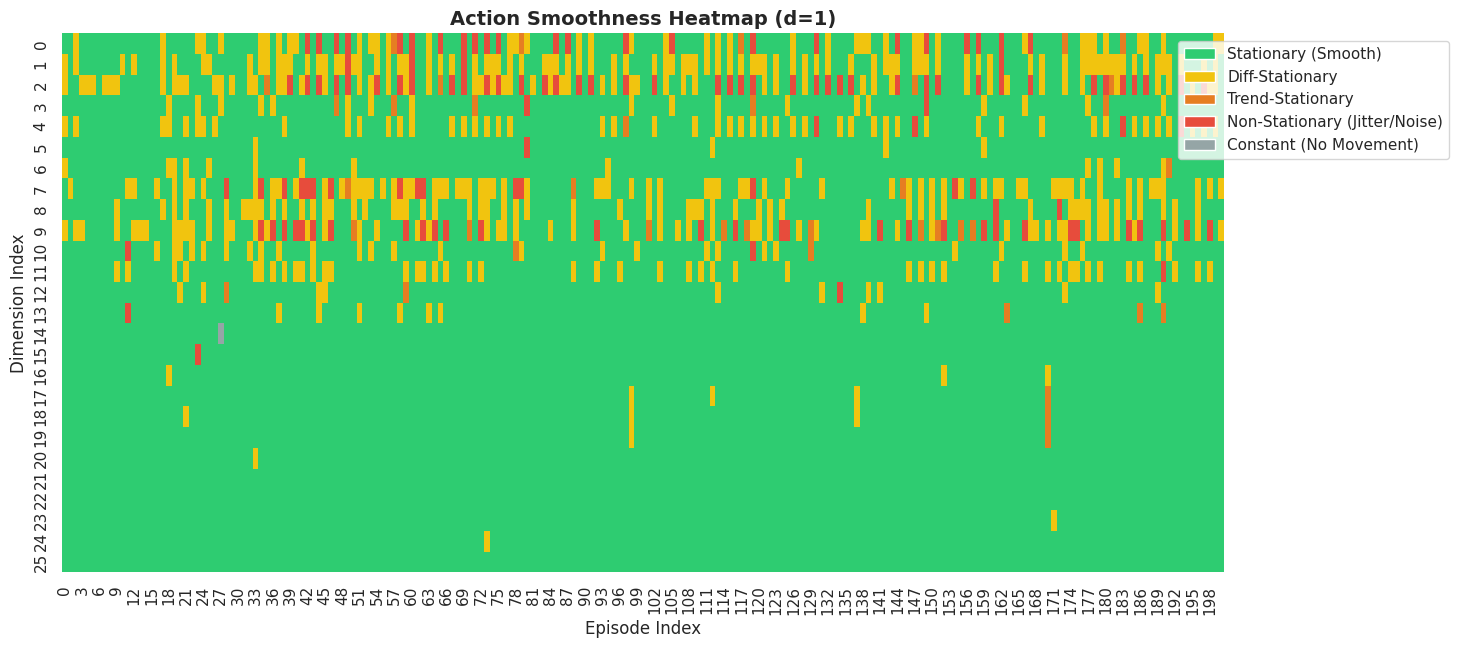

In [10]:
if 'df_within' in locals():
    df_stream = df_within[df_within["stream"] == STREAM].copy()
    
    if not df_stream.empty:
        verdict_map = {"stationary": 0, "difference_stationary": 1, "trend_stationary": 2, "non_stationary": 3, "constant": 4}
        df_stream["verdict_num"] = df_stream["verdict"].map(verdict_map)
        pivot_df = df_stream.pivot(index="dim", columns="episode", values="verdict_num")
        
        plt.figure(figsize=(15, 7))
        cmap = sns.color_palette(["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c", "#95a5a6"])
        sns.heatmap(pivot_df, cmap=cmap, cbar=False, vmin=0, vmax=4)
        
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor="#2ecc71", label="Stationary (Smooth)"),
            Patch(facecolor="#f1c40f", label="Diff-Stationary"),
            Patch(facecolor="#e67e22", label="Trend-Stationary"),
            Patch(facecolor="#e74c3c", label="Non-Stationary (Jitter/Noise)"),
            Patch(facecolor="#95a5a6", label="Constant (No Movement)")
        ]
        plt.legend(handles=legend_elements, loc="upper right", bbox_to_anchor=(1.2, 1))
        plt.title(f"{STREAM.capitalize()} Smoothness Heatmap (d={DIFF_ORDER})", fontsize=14, fontweight="bold")
        plt.xlabel("Episode Index"); plt.ylabel("Dimension Index")
        plt.show()
    else:
        print(f"No data for stream: {STREAM}")

## Phase 2: Episode Metrics Over Time

Checking for trends in trajectory length and movement intensity (variation).

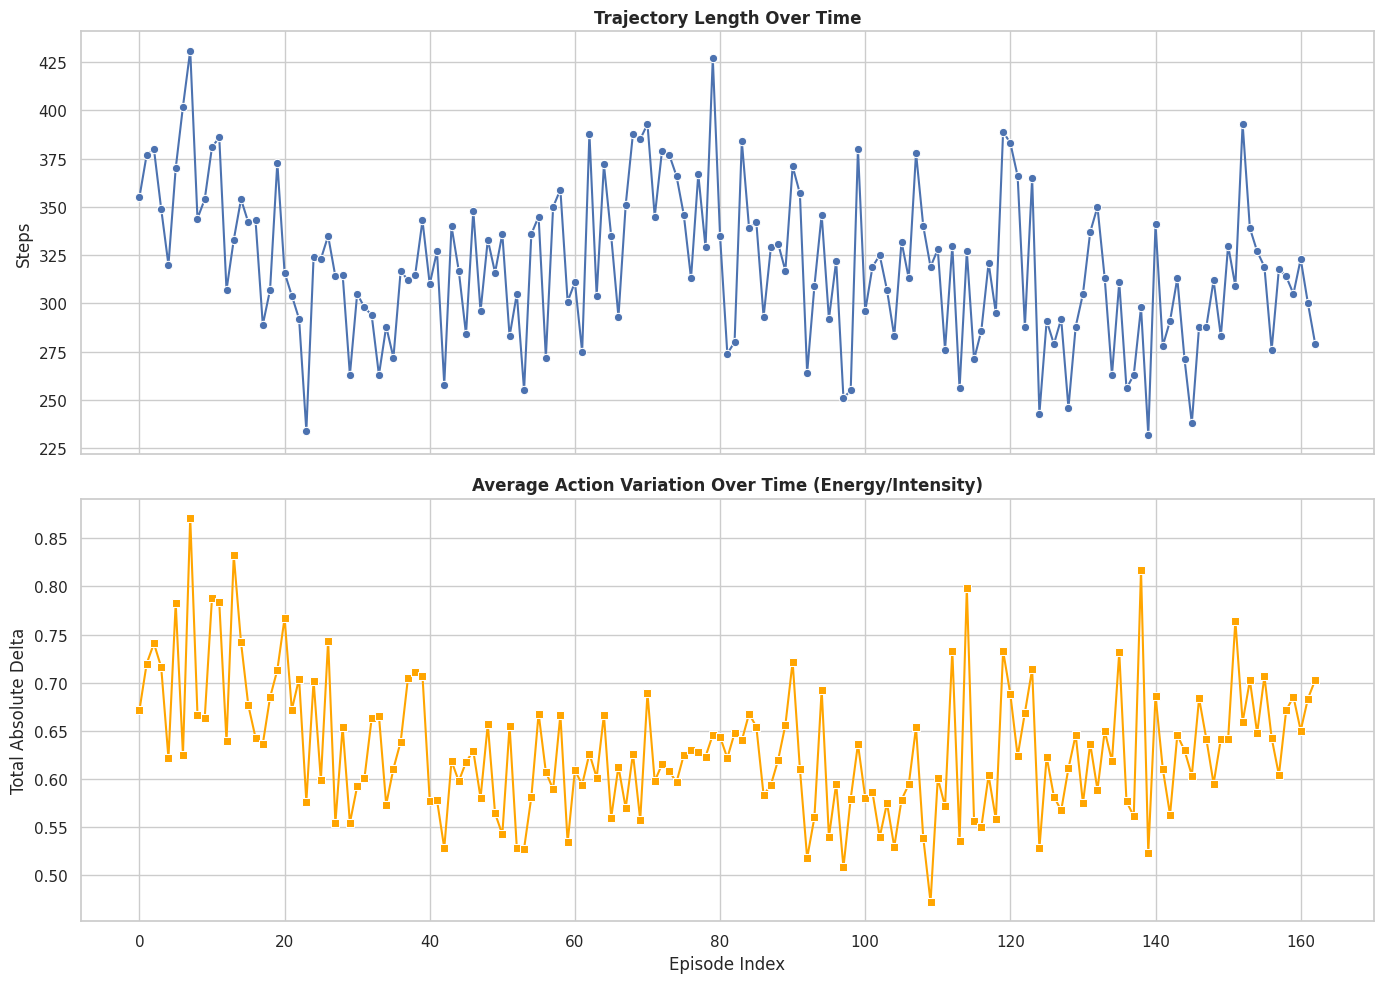

In [5]:
if 'df_metrics' in locals():
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    # Trajectory Length
    sns.lineplot(data=df_metrics, x="episode", y="trajectory_length", ax=ax1, marker="o")
    ax1.set_title("Trajectory Length Over Time", fontweight="bold")
    ax1.set_ylabel("Steps")
    
    # Total Variation (e.g., Action Dimension 0)
    var_cols = [c for c in df_metrics.columns if "var_action" in c]
    if var_cols:
        # Plot mean variation across action dimensions
        df_metrics['mean_action_var'] = df_metrics[var_cols].mean(axis=1)
        sns.lineplot(data=df_metrics, x="episode", y="mean_action_var", ax=ax2, color="orange", marker="s")
        ax2.set_title("Average Action Variation Over Time (Energy/Intensity)", fontweight="bold")
        ax2.set_ylabel("Total Absolute Delta")
    
    plt.xlabel("Episode Index")
    plt.tight_layout()
    plt.show()

## Phase 3: Across-Episode Drift Statistical Significance

Lower p-values indicate higher probability of drift between chronological buckets.

/tmp/ipykernel_27276/276251187.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_drift_sorted, x="p_value", y="metric", palette=colors)


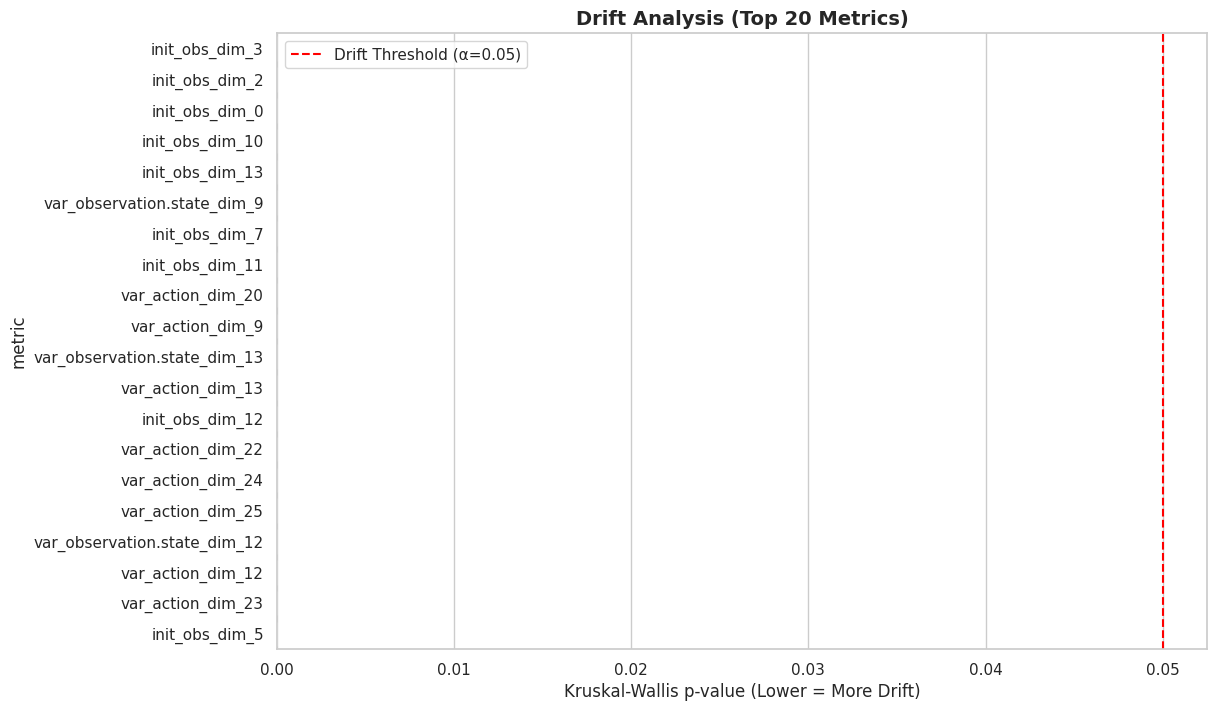

In [6]:
if 'df_drift' in locals() and not df_drift.empty:
    df_drift_sorted = df_drift.sort_values("p_value", ascending=True).head(20)
    
    plt.figure(figsize=(12, 8))
    colors = ["#e74c3c" if p < ALPHA else "#3498db" for p in df_drift_sorted["p_value"]]
    sns.barplot(data=df_drift_sorted, x="p_value", y="metric", palette=colors)
    
    plt.axvline(x=ALPHA, color="red", linestyle="--", label=f"Drift Threshold (α={ALPHA})")
    plt.title("Drift Analysis (Top 20 Metrics)", fontsize=14, fontweight="bold")
    plt.xlabel("Kruskal-Wallis p-value (Lower = More Drift)")
    plt.legend()
    plt.show()